# AG-HYPOPT · Trial 13

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twelve trials; the low-sw map is complete for every family. Best: **trial_11** `cvm_fwhm` **0.0760**
(sw 0.1956); `cvm_fwhm` is a flat basin near sw ~0.20 (sw 0.1816 -> 0.0791, 0.1956 -> 0.0760,
0.2074 -> 0.0764, 0.2345 -> 0.0777). At the winning sw the other families are: `kde` 0.0830 (`w1_2d`
0.0849, `w1_fwhm` 0.0923, `energy_2d` 0.1021) - all above the KDE control (0.080328), so `cvm_fwhm` is
the only family to beat it. The win is a gamma-channel effect (best campaign gamma RMSE 2.28 / rel
23.6 %). No divergences. Phase `trials` (12/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_13'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (12/5 trials)
ID |     ei | params
 1 | 2.7752 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.24692959417597468}
 2 | 1.2655 | {"loss_family": "energy_2d", "sigma_weight": 0.9464657804460633}
 3 | 2.9401 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.9104071780658378}
 4 | 3.3049 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19102019612807303}
 5 | 2.3980 | {"loss_family": "kde", "sigma_weight": 0.2047024063435906}
 6 | 1.7287 | {"loss_family": "mmd_2d", "sigma_weight": 0.18386749212199538}
 7 | 0.8074 | {"loss_family": "energy_2d", "sigma_weight": 0.25184534183474383}
 8 | 1.6026 | {"loss_family": "w1_fwhm", "sigma_weight": 0.2274927319049811}
 9 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.5989776523667713}
10 |      - | {"loss_family": "kde", "sigma_weight": 0.9672952777915866}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI is now dominated by `cvm_fwhm` in the winning basin (candidates 4, 3, 1). With the family map complete
and the optimum bracketed, the productive use of a trial is exploitation of the leader - and the highest
information within that is a fresh-draw confirmation of the best region. Candidate 4 (`cvm_fwhm`, sw
0.1910, ei 3.3049, the top) sits just inside the basin on the low side of trial_11 (sw 0.1956 -> 0.0760),
so it both exploits and checks that the ~0.076 level is reproducible rather than a single-seed
fluctuation. Candidate 3 (sw 0.9104) and candidate 1 (sw 0.2469) are higher-/lower-sw points that the
existing brackets already cover.

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19102019612807303}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.73 | γ 8.5 -> 5.97 | NLL 0.83


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.62 | γ 14.1 -> 14.04 | NLL 0.14


Running 3nW Trans100 ... 

μ 175.71 -> 97.21 | γ 14.1 -> 13.44 | NLL 0.30



Total: 7.8 min


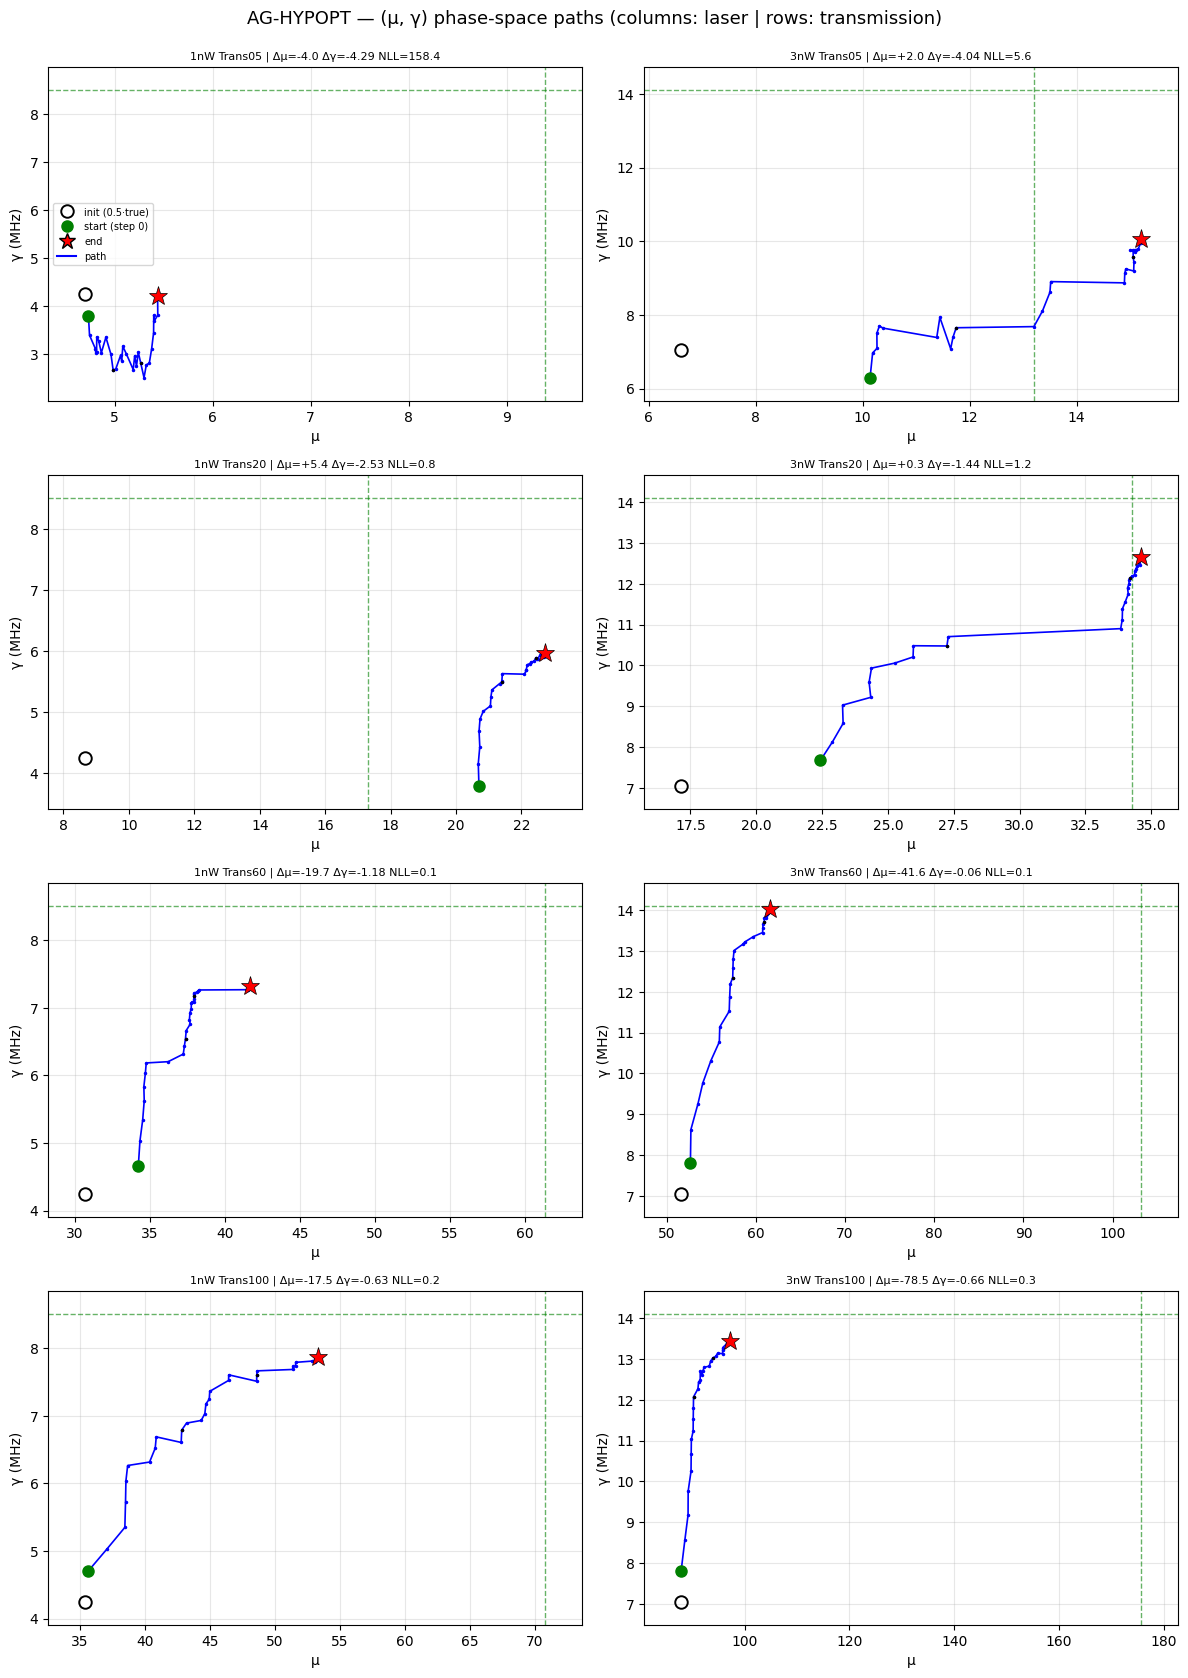

trial finished in 7.9 min
objective = 0.0733 ± 0.0202
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.73   +31.2 |     8.50    5.97   -29.8
1nW Trans60       61.37   41.66   -32.1 |     8.50    7.32   -13.9
1nW Trans100       70.82   53.35   -24.7 |     8.50    7.87    -7.4
3nW Trans05       13.20   15.21   +15.2 |    14.10   10.06   -28.6
3nW Trans20       34.28   34.63    +1.0 |    14.10   12.66   -10.2
3nW Trans60      103.20   61.62   -40.3 |    14.10   14.04    -0.4
3nW Trans100      175.71   97.21   -44.7 |    14.10   13.44    -4.7

weighted objective (T-graded, cap=1.0) = 0.0733 | diverged cells: 0
μ: RMSE 32.851 (rel 32.1%, bias -19.181) | γ: RMSE 2.382 (rel 24.0%, bias -1.854)


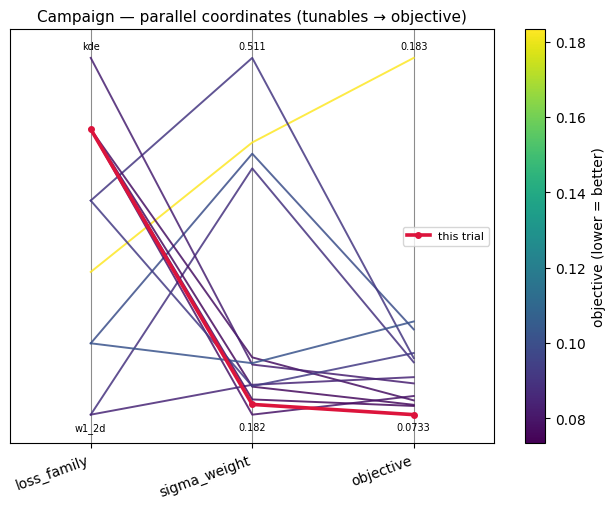

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1910}` (candidate 4, top EI).
Trial time 7.9 min, objective **0.0733 +/- 0.0202**, **0 diverged cells**. A **new campaign best**,
improving on trial_11 (0.0760 at sw 0.1956) and now ~0.007 below the KDE control (0.080328).

**The `cvm_fwhm` basin.** sw 0.1816 -> 0.0791, **sw 0.1910 -> 0.0733**, sw 0.1956 -> 0.0760, sw 0.2074 ->
0.0764, sw 0.2345 -> 0.0777. The bottom is around sw ~0.19-0.20 and the scatter within the basin
(~0.003) is comparable to the trial-to-trial seed noise, so the basin is genuinely flat and the family
reliably sits at ~0.073-0.077, all under the control.

**Per-cell behaviour.**

- 1nW Trans05: mu -42.1 %, gamma 8.5 -> 4.21 (-50.4 %).
- 1nW Trans20: mu +31.2 %, gamma -29.8 %.
- 1nW Trans60 / Trans100: mu -32.1 % / -24.7 %, gamma -13.9 % / -7.4 %.
- 3nW Trans05 / Trans20: mu +15.2 % / +1.0 %, gamma -28.6 % / -10.2 %.
- 3nW Trans60 / Trans100: mu -40.3 % / -44.7 %, gamma -0.4 % / -4.7 % - high-T gamma essentially exact.

**Aggregates.** mu: RMSE 32.85 (rel 32.1 %), bias -19.18; gamma: RMSE 2.38 (rel 24.0 %), bias -1.85 -
both in the family's healthy range.

**Summary:** `cvm_fwhm` at sw 0.1910 sets a new campaign best of 0.0733, deepening the confirmed sw ~0.19
basin and putting the family ~0.007 under the KDE control.
**Key insight:** The `cvm_fwhm` win is robust and reproducible (four points in 0.073-0.079 across sw
0.18-0.23), so it is the campaign's clear winner over the KDE control.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1910 sets a new campaign best of 0.0733, deepening the confirmed sw ~0.19 basin and putting the family ~0.007 under the KDE control.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm win is robust and reproducible (four points in 0.073-0.079 across sw 0.18-0.23), so it is the campaign clear winner over the KDE control.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_13 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_14.ipynb. Open it and follow its cells from the top.
